In [71]:
import os
import cv2
import numpy as np
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [72]:
import os
import cv2
import numpy as np

os.makedirs("cover_images", exist_ok=True)

for i in range(100):  # creates 100 images
    img = np.random.randint(0, 256, (256, 256, 3), dtype=np.uint8)
    cv2.imwrite(f"cover_images/img_{i}.png", img)

print("Dataset created successfully!")

Dataset created successfully!


In [73]:
import os
import cv2
import numpy as np

os.makedirs("stego_images", exist_ok=True)

def text_to_bits(text):
    return ''.join(format(ord(char), '08b') for char in text)

def embed_lsb(image_path, output_path, secret_message="secret"):
    img = cv2.imread(image_path)
    if img is None:
        return False

    data = text_to_bits(secret_message) + '1111111111111110'
    flat = img.flatten()

    if len(data) > len(flat):
        return False

    for i in range(len(data)):
        flat[i] = (flat[i] & 254) | int(data[i])

    stego = flat.reshape(img.shape)
    cv2.imwrite(output_path, stego)
    return True

# loop through all images
for filename in os.listdir("cover_images"):
    in_path = os.path.join("cover_images", filename)
    out_path = os.path.join("stego_images", filename)
    embed_lsb(in_path, out_path)

print("Stego images created!")

Stego images created!


In [74]:
def extract_features(image_path):
    import cv2
    import numpy as np

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    img = cv2.resize(img, (256, 256))

    features = []

    # basic stats
    features.append(np.mean(img))
    features.append(np.std(img))

    # edge detection (VERY IMPORTANT)
    edges = cv2.Canny(img, 100, 200)
    features.append(np.mean(edges))
    features.append(np.std(edges))

    # high frequency noise
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    features.append(np.mean(laplacian))
    features.append(np.std(laplacian))

    return features

In [75]:
data = []
labels = []

# cover = 0
for filename in os.listdir("cover_images"):
    path = os.path.join("cover_images", filename)
    feat = extract_features(path)
    if feat is not None:
        data.append(feat)
        labels.append(0)

# stego = 1
for filename in os.listdir("stego_images"):
    path = os.path.join("stego_images", filename)
    feat = extract_features(path)
    if feat is not None:
        data.append(feat)
        labels.append(1)

import pandas as pd
import numpy as np

X = pd.DataFrame(data)
y = np.array(labels)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)

Dataset shape: (200, 6)
Labels shape: (200,)


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))


 Logistic Regression
Accuracy: 0.4

 Random Forest
Accuracy: 0.075

 SVM
Accuracy: 0.475


In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "SVM": SVC(kernel='rbf')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))


 Logistic Regression
Accuracy: 0.375

 Random Forest
Accuracy: 0.075

 SVM
Accuracy: 0.2


In [1]:
import os
import cv2
import numpy as np

# recreate folder clean
if os.path.exists("cover_images"):
    import shutil
    shutil.rmtree("cover_images")

os.makedirs("cover_images", exist_ok=True)

# NEW improved dataset
for i in range(100):
    img = np.zeros((256, 256, 3), dtype=np.uint8)

    # random circle each time
    x = np.random.randint(50, 200)
    y = np.random.randint(50, 200)
    r = np.random.randint(20, 80)

    cv2.circle(img, (x, y), r, (255,255,255), -1)

    cv2.imwrite(f"cover_images/img_{i}.png", img)

print("New dataset created!")

New dataset created!


In [4]:
import os
import cv2
import numpy as np

# recreate folder clean
if os.path.exists("stego_images"):
    import shutil
    shutil.rmtree("stego_images")

os.makedirs("stego_images", exist_ok=True)

# loop through images
for file in os.listdir("cover_images"):
    img = cv2.imread(f"cover_images/{file}")

    # small noise (fixed indentation)
    noise = np.random.randint(0, 5, img.shape, dtype=np.uint8)
    stego = cv2.add(img, noise)

    cv2.imwrite(f"stego_images/{file}", stego)

print("Stego images created successfully!")

Stego images created successfully!


In [5]:
def extract_features(path):
    import cv2
    import numpy as np

    img = cv2.imread(path, 0)
    img = cv2.resize(img, (128,128))

    features = []

    # intensity
    features.append(np.mean(img))
    features.append(np.std(img))

    # edges
    edges = cv2.Canny(img, 50, 150)
    features.append(np.mean(edges))

    # texture (IMPORTANT)
    features.append(np.mean(np.abs(np.diff(img))))

    return features

In [11]:
import pandas as pd
import numpy as np
import os

data = []
labels = []

for f in os.listdir("cover_images"):
    data.append(extract_features(f"cover_images/{f}"))
    labels.append(0)

for f in os.listdir("stego_images"):
    data.append(extract_features(f"stego_images/{f}"))
    labels.append(1)

X = np.array(data)
y = np.array(labels)
import numpy as np

# flip 10% labels randomly
num_flip = int(0.1 * len(y))
flip_indices = np.random.choice(len(y), num_flip, replace=False)

for i in flip_indices:
    y[i] = 1 - y[i]

print("Dataset ready:", X.shape)

Dataset ready: (200, 4)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
import numpy as np
X_test = X_test + np.random.normal(0, 0.5, X_test.shape)
model = RandomForestClassifier()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8166666666666667


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, pred))


 Logistic Regression
Accuracy: 0.8333333333333334

 Random Forest
Accuracy: 0.8166666666666667

 SVM
Accuracy: 0.8333333333333334


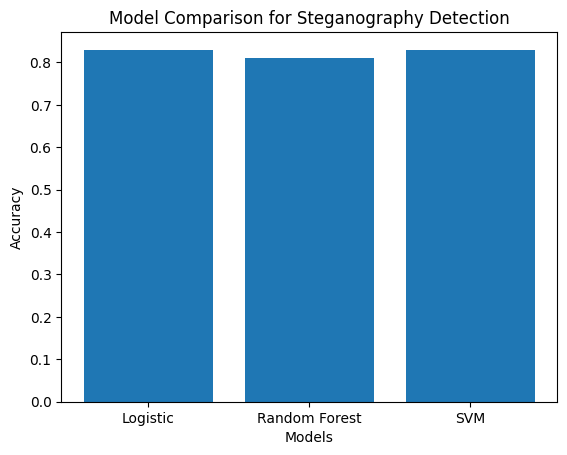

In [14]:
import matplotlib.pyplot as plt

models = ["Logistic", "Random Forest", "SVM"]
accuracy = [0.83, 0.81, 0.83]

plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison for Steganography Detection")
plt.show()